In [26]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

# Create dataset
X, y = make_blobs(
    n_samples=1000,
    centers=3,
    n_features=2,
    random_state=42
)



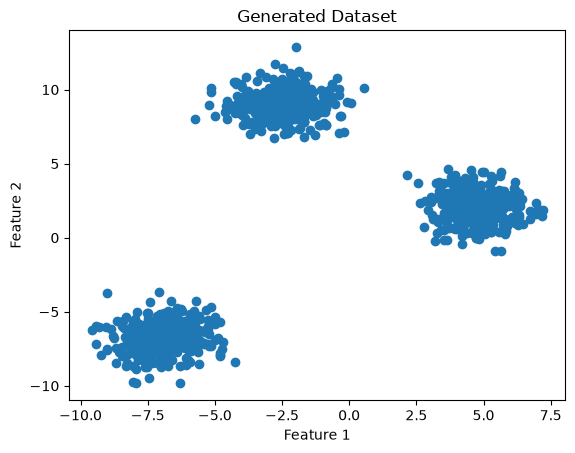

In [27]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("Generated Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [28]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    
    wcss.append(kmeans.inertia_)

In [29]:
wcss

[66571.67201089086,
 18773.018255690855,
 1950.8814994726636,
 1713.287669083445,
 1500.1243636991387,
 1272.6670990058938,
 1122.3486266335076,
 991.459560625309,
 872.8169321468993,
 795.3233426406929]

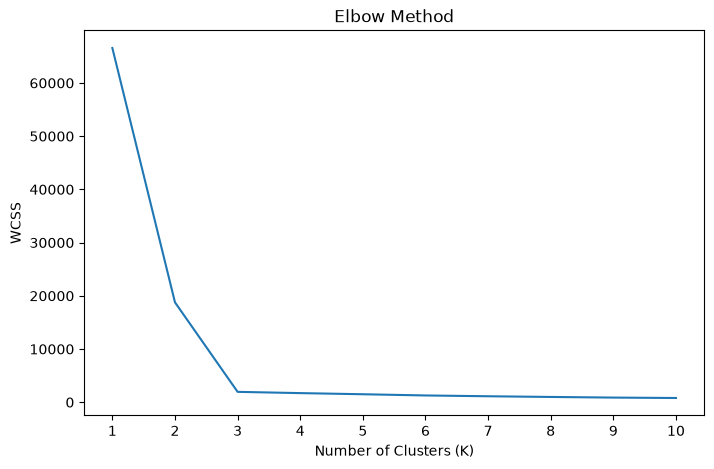

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11),wcss)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.xticks(range(1, 11))

plt.show()

In [31]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X)

centroids = kmeans.cluster_centers_

print("Selected K =", 3)
print("Final WCSS =", kmeans.inertia_)
print("Centroids:")
print(centroids)

Selected K = 3
Final WCSS = 1950.8814994726638
Centroids:
[[-2.52414179  9.00394283]
 [-6.86656253 -6.78519427]
 [ 4.7286341   2.05557266]]


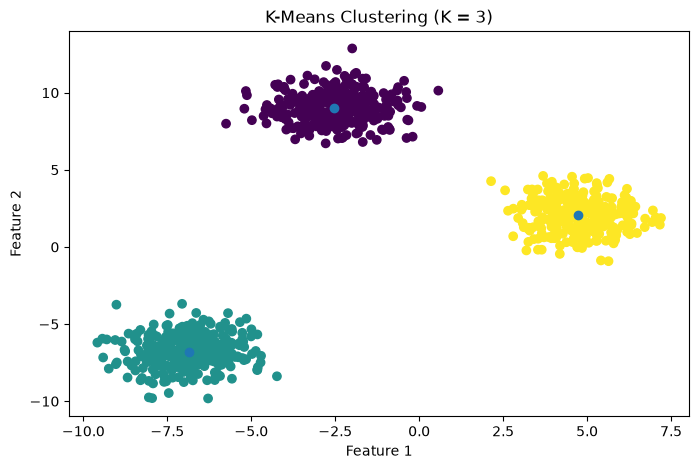

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,

)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='o',

)

plt.title("K-Means Clustering (K = 3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [33]:
pip install kneed



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## How to get Value of K using KNEED LOCATOR

In [34]:
from kneed import KneeLocator

kl = KneeLocator(
    range(1, 11),
    wcss,
    curve='convex',
    direction='decreasing'
)

print(kl.elbow)

3


In [39]:
## Silhouette score
from sklearn.metrics import silhouette_score

silhouette_coefficients = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X)

    score = silhouette_score(X, kmeans.labels_)
    silhouette_coefficients.append(score)

In [40]:
silhouette_coefficients


[0.7052841810631846,
 0.8435705873891369,
 0.658100377582707,
 0.6722288487934072,
 0.5181745032612205,
 0.3256447713888835,
 0.3293446100986066,
 0.33254288310352453,
 0.3209934319479446]